<a href="https://colab.research.google.com/github/kasrasa/ViT-VLM-experiments/blob/VLA-Experiments/VLA_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U lerobot
!pip install -q "lerobot[dataset]" av datasets
!pip install --no-binary=av av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 67.3 MB/s eta 0:00:00


In [2]:
import os
import math
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, Subset
import torch.nn.functional as F
from torch import nn
from torchvision.models import resnet50, ResNet50_Weights, convnext_tiny, ConvNeXt_Tiny_Weights
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from lerobot.datasets import LeRobotDataset

In [3]:
DATASET_REPO_ID = "lerobot/pusht" # "lerobot/svla_so101_pickplace"

dataset = LeRobotDataset(DATASET_REPO_ID)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print(torch.cuda.is_available())

print(dataset)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Using device: cuda
True
LeRobotDataset({
    Repository ID: 'lerobot/pusht',
    Number of selected episodes: '206',
    Number of selected samples: '25650',
    Features: '['observation.image', 'observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.reward', 'next.done', 'next.success', 'index', 'task_index']',
})


In [4]:
sample = dataset[0]

print("Keys in one sample:")
print(sample.keys())

print("\nDetails of dataset[0]:")
for key, value in sample.items():
    print("\n" + "-" * 80)
    print("KEY:", key)
    print("TYPE:", type(value))

    if hasattr(value, "shape"):
        print("SHAPE:", value.shape)
        print("DTYPE:", getattr(value, "dtype", None))
        print("VALUE:")
        print(value)
    else:
        print("VALUE:")
        print(value)

Keys in one sample:
dict_keys(['observation.image', 'observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.reward', 'next.done', 'next.success', 'index', 'task_index', 'task'])

Details of dataset[0]:

--------------------------------------------------------------------------------
KEY: observation.image
TYPE: <class 'torch.Tensor'>
SHAPE: torch.Size([3, 96, 96])
DTYPE: torch.float32
VALUE:
tensor([[[1.0000, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 1.0000],
         [0.9725, 0.9098, 0.9098,  ..., 0.9098, 0.9098, 0.9725],
         [0.9725, 0.9098, 0.9725,  ..., 1.0000, 0.9098, 0.9725],
         ...,
         [0.9725, 0.9098, 1.0000,  ..., 1.0000, 0.9098, 0.9725],
         [0.9725, 0.9098, 0.9098,  ..., 0.9098, 0.9098, 0.9725],
         [1.0000, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 1.0000]],

        [[1.0000, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 1.0000],
         [0.9725, 0.9098, 0.9098,  ..., 0.9098, 0.9098, 0.9725],
         [0.9725, 0.9098, 0.9725,  ..., 1.0

In [5]:
first_episode_id = int(dataset[0]["episode_index"])
print("First episode ID:", first_episode_id)

episode_indices = []

for i in range(len(dataset)):
    episode_id = int(dataset[i]["episode_index"])

    if episode_id == first_episode_id:
        episode_indices.append(i)
    elif len(episode_indices) > 0:
        break

print("Number of samples/frames in first episode:", len(episode_indices))
print("First dataset index in episode:", episode_indices[0])
print("Last dataset index in episode:", episode_indices[-1])

print("\nFirst frame_index:", dataset[episode_indices[0]]["frame_index"])
print("Last frame_index:", dataset[episode_indices[-1]]["frame_index"])

print("\nFirst timestamp:", dataset[episode_indices[0]]["timestamp"])
print("Last timestamp:", dataset[episode_indices[-1]]["timestamp"])

First episode ID: 0
Number of samples/frames in first episode: 161
First dataset index in episode: 0
Last dataset index in episode: 160

First frame_index: tensor(0)
Last frame_index: tensor(160)

First timestamp: tensor(0.)
Last timestamp: tensor(16.)


In [6]:
def find_keys_containing(sample, keywords):
  keys = []
  for key, value in sample.items():
    key_lower = key.lower()
    if any(word in key_lower for word in keywords):
      keys.append(key)
  return keys

image_keys = find_keys_containing(sample, ["image", "rgb", "camera"])
action_keys = find_keys_containing(sample, ["action"])
state_keys = find_keys_containing(sample, ["state", "joint", "qpos", "robot"])
language_keys = find_keys_containing(sample, ["task", "instruction", "language", "text"])
episode_keys = find_keys_containing(dataset[0], ["episode"])
frame_keys = find_keys_containing(dataset[0], ["frame", "index", "timestamp"])


print("Possible image keys:", image_keys)
print("Possible action keys:", action_keys)
print("Possible state keys:", state_keys)
print("Possible language/task keys:", language_keys)
print("Possible episode keys:", episode_keys)
print("Possible frame/time keys:", frame_keys)

Possible image keys: ['observation.image']
Possible action keys: ['action']
Possible state keys: ['observation.state']
Possible language/task keys: ['task_index', 'task']
Possible episode keys: ['episode_index']
Possible frame/time keys: ['episode_index', 'frame_index', 'timestamp', 'index', 'task_index']


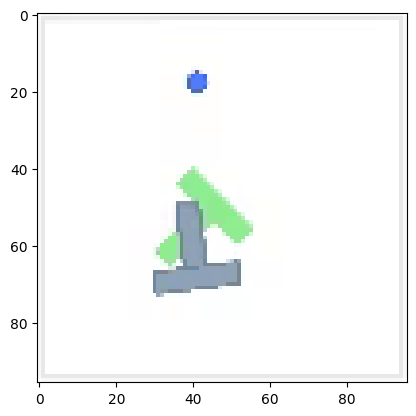

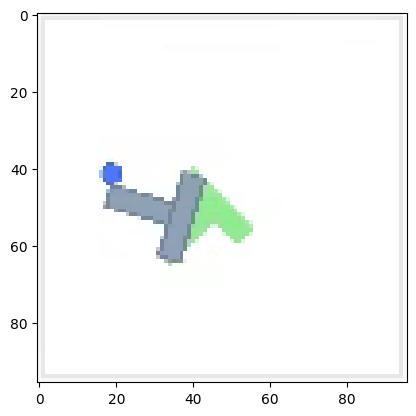

In [7]:
def show_image_tensor(image_tensor):
  img = (image_tensor.detach().cpu().permute(1,2,0).numpy()*255).astype(np.uint8)
  plt.imshow(img)
  plt.show()

show_image_tensor(sample[image_keys[0]])
show_image_tensor(dataset[100][image_keys[0]])
# show_image_tensor(sample[image_keys[1]])
# show_image_tensor(dataset[100][image_keys[1]])

In [8]:
if len(action_keys) > 0:
  action_key = action_keys[0]

  actions = []

  max_samples = min(len(dataset), 5000)
  for idx in tqdm(range(max_samples), desc="Collecting actions"):
    action = dataset[idx][action_key]

    action = action.detach().cpu().numpy() if isinstance(action, torch.Tensor) else action

    action = np.asarray(action).reshape(-1)
    actions.append(action)

  actions = np.stack(actions)

  print("Actions array shape:", actions.shape)

  action_stats_df = pd.DataFrame({
      "dim": np.arange(actions.shape[1]),
      "mean": actions.mean(axis=0),
      "std": actions.std(axis=0),
      "min": actions.min(axis=0),
      "max": actions.max(axis=0),
  })

  display(action_stats_df)

Actions array shape: (5000, 2)


,dim,mean,std,min,max
0,0,225.967804,103.186333,23.0,511.0
1,1,281.851410,99.482811,36.0,498.0


In [9]:
if len(state_keys) > 0:
  state_key = state_keys[0]

  states = []

  max_samples = min(len(dataset), 50000)
  for idx in tqdm(range(max_samples), desc="Collecting actions"):
    state = dataset[idx][state_key]

    state = state.detach().cpu().numpy() if isinstance(state, torch.Tensor) else state

    state = np.asarray(state).reshape(-1)
    states.append(state)

  states = np.stack(states)

  print("States array shape:", states.shape)

  state_stats_df = pd.DataFrame({
      "dim": np.arange(states.shape[1]),
      "mean": states.mean(axis=0),
      "std": states.std(axis=0),
      "min": states.min(axis=0),
      "max": states.max(axis=0),
  })

  display(state_stats_df)

States array shape: (25650, 2)


,dim,mean,std,min,max
0,0,229.111603,101.854828,13.456424,496.146179
1,1,293.311157,96.489395,32.938293,510.957886


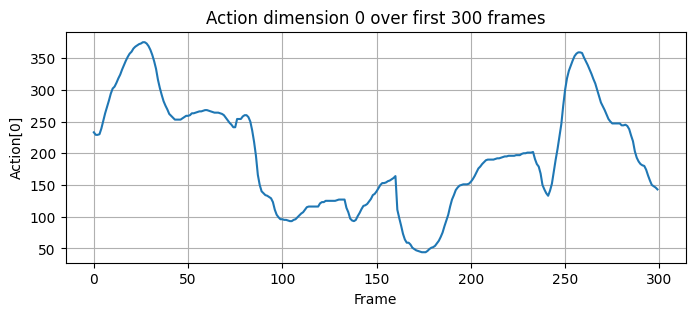

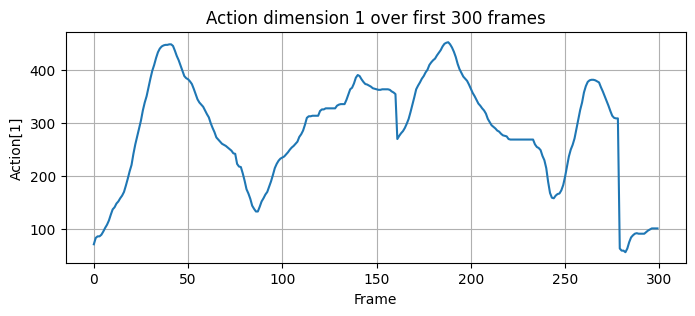

In [10]:
if len(action_keys) > 0:
    num_steps_to_plot = min(300, actions.shape[0])
    num_action_dims = actions.shape[1]

    for dim in range(num_action_dims):
        plt.figure(figsize=(8, 3))
        plt.plot(actions[:num_steps_to_plot, dim])
        plt.title(f"Action dimension {dim} over first {num_steps_to_plot} frames")
        plt.xlabel("Frame")
        plt.ylabel(f"Action[{dim}]")
        plt.grid(True)
        plt.show()

Using episode key: episode_index
Number of episodes inspected: 40


,episode_id,num_frames
0,0,161
1,1,118
2,2,141
3,3,159
4,4,159
5,5,157
6,6,69
7,7,169
8,8,80
9,9,134


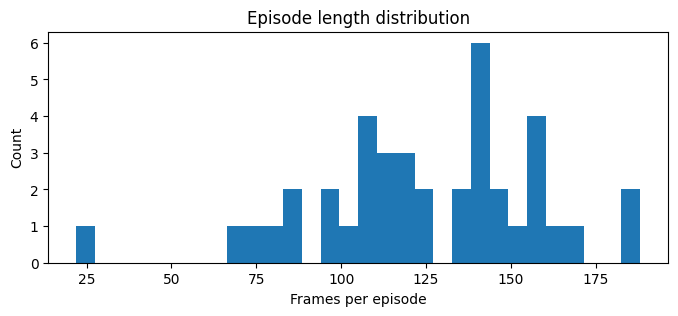

In [11]:
if len(episode_keys) > 0:
    episode_key = episode_keys[0]
    print("Using episode key:", episode_key)

    episode_ids = []

    max_samples = min(len(dataset), 5000)

    for idx in range(max_samples):
        value = dataset[idx][episode_key]

        value = int(value.item()) if isinstance(value, torch.Tensor) else int(value)

        episode_ids.append(value)

    episode_ids = np.asarray(episode_ids)

    unique_ids, count = np.unique(episode_ids, return_counts=True)

    episode_df = pd.DataFrame({
        "episode_id": unique_ids,
        "num_frames": count,
    })

    print("Number of episodes inspected:", len(episode_df))
    display(episode_df.head(20))

    plt.figure(figsize=(8, 3))
    plt.hist(episode_df["num_frames"], bins=30)
    plt.title("Episode length distribution")
    plt.xlabel("Frames per episode")
    plt.ylabel("Count")
    plt.show()
else:
    print("No episode key found.")

In [12]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def to_float_tensor(x):
    if isinstance(x, torch.Tensor):
        return x.float()
    return torch.tensor(x, dtype=torch.float32)


def get_scalar_value(x):
    if isinstance(x, torch.Tensor):
        return int(x.item())
    return int(x)

Episode 0 has 161 frames in inspected range.


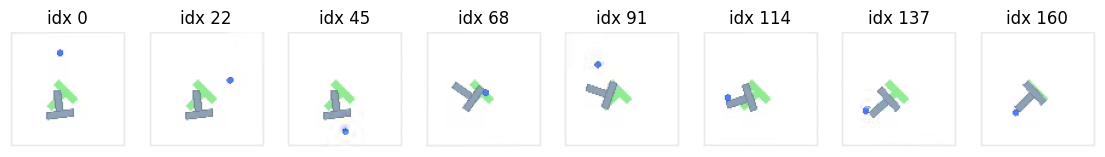

In [13]:
if len(image_keys) > 0 and len(episode_keys) > 0:
    image_key = image_keys[0]
    episode_key = episode_keys[0]

    target_episode = get_scalar_value(dataset[0][episode_key])

    episode_indices = []
    for idx in range(min(len(dataset), 5000)):
        if get_scalar_value(dataset[idx][episode_key]) == target_episode:
            episode_indices.append(idx)

    print(f"Episode {target_episode} has {len(episode_indices)} frames in inspected range.")

    # Pick up to 8 evenly spaced frames from this episode.
    if len(episode_indices) > 0:
        chosen = np.linspace(0, len(episode_indices) - 1, min(8, len(episode_indices))).astype(int)
        chosen_indices = [episode_indices[i] for i in chosen]

        plt.figure(figsize=(14, 4))

        for plot_i, dataset_idx in enumerate(chosen_indices):
            img = dataset[dataset_idx][image_key].detach().cpu()

            if img.ndim == 3 and img.shape[0] in [1, 3, 4]:
                img = img.permute(1, 2, 0)

            img = img.numpy()
            if img.dtype != np.uint8:
                img = np.clip(img, 0, 1)

            plt.subplot(1, len(chosen_indices), plot_i + 1)
            plt.imshow(img)
            plt.title(f"idx {dataset_idx}")
            plt.axis("off")

        plt.show()
else:
    print("Need both image key and episode key to visualize a trajectory.")

In [14]:
if len(language_keys) == 0:
    print("No language/task key found.")
else:
    for key in language_keys:
        print("\nKey:", key)
        values = []

        for idx in range(min(len(dataset), 20)):
            value = dataset[idx][key]
            values.append(value)

        for i, value in enumerate(values[:10]):
            print(f"{i}: {value}")


Key: task_index
0: 0
1: 0
2: 0
3: 0
4: 0
5: 0
6: 0
7: 0
8: 0
9: 0

Key: task
0: Push the T-shaped block onto the T-shaped target.
1: Push the T-shaped block onto the T-shaped target.
2: Push the T-shaped block onto the T-shaped target.
3: Push the T-shaped block onto the T-shaped target.
4: Push the T-shaped block onto the T-shaped target.
5: Push the T-shaped block onto the T-shaped target.
6: Push the T-shaped block onto the T-shaped target.
7: Push the T-shaped block onto the T-shaped target.
8: Push the T-shaped block onto the T-shaped target.
9: Push the T-shaped block onto the T-shaped target.


In [15]:
def split_dataset(dataset, train_split = 0.8, seed = 42):
  num_episodes = dataset.num_episodes
  episode_indices = np.arange(num_episodes)

  np.random.seed(seed)
  np.random.shuffle(episode_indices)

  train_size = int(train_split * num_episodes)
  train_episode_indices = episode_indices[:train_size]
  val_episode_indices = episode_indices[train_size:]

  train_indices = []
  val_indices = []

  for idx in tqdm(range(len(dataset)), desc = "collecting dataset indices"):
    episode_id = dataset[idx]["episode_index"]
    if episode_id in train_episode_indices:
      train_indices.append(idx)
    elif episode_id in val_episode_indices:
      val_indices.append(idx)

  return train_episode_indices, val_episode_indices, train_indices, val_indices

train_episode_indices, val_episode_indices, train_indices, val_indices = split_dataset(dataset)
print("Number of training episodes:", len(train_episode_indices))
print("Number of validation episodes:", len(val_episode_indices))
print("sample train episodes: ", train_episode_indices[:5])
print("sample val episodes: ", val_episode_indices[:5])
print("Number of training samples:", len(train_indices))
print("Number of validation samples:", len(val_indices))
print("sample train indices: ", np.random.randint(0,len(train_indices[:5]),10))
print("sample val indices: ", np.random.randint(0,len(val_indices[:5]),10))

collecting dataset indices:   0%|          | 0/25650 [00:00<?, ?it/s]

Number of training episodes: 164
Number of validation episodes: 42
sample train episodes:  [ 15   9 201  82  68]
sample val episodes:  [ 72 181 134 172 189]
Number of training samples: 20353
Number of validation samples: 5297
sample train indices:  [3 1 3 2 2 0 4 3 1 2]
sample val indices:  [0 0 3 2 4 2 3 3 2 3]


In [16]:
def collect_actions(dataset, indices, action_key):
  actions = []
  for ind in tqdm(indices, desc="Collecting actions"):
    action = to_numpy(dataset[ind][action_key]).reshape(-1).astype(np.float32)
    actions.append(action)

  return np.stack(actions)

train_actions = collect_actions(dataset, train_indices, action_keys[0])
val_actions = collect_actions(dataset, val_indices, action_keys[0])

print("train actions shape: ", train_actions.shape)
print("val actions shape: ", val_actions.shape)

train actions shape:  (20353, 2)
val actions shape:  (5297, 2)


In [17]:
def collect_states(dataset, indices, state_key):
  states = []
  for ind in tqdm(indices, desc="Collecting states"):
    state = to_numpy(dataset[ind][state_key]).reshape(-1).astype(np.float32)
    states.append(state)

  return np.stack(states)

train_states = collect_states(dataset, train_indices, state_keys[0])
val_states = collect_states(dataset, val_indices, state_keys[0])

print("train states shape: ", train_states.shape)
print("val states shape: ", val_states.shape)

train states shape:  (20353, 2)
val states shape:  (5297, 2)


In [18]:
def best_row(history_df, metric="val_mae"):
    return history_df.loc[history_df[metric].idxmin()]


def per_action_dim_metrics(y_true, y_pred):
  y_true = np.asarray(y_true)
  y_pred = np.asarray(y_pred)

  error = y_pred - y_true

  mae = np.mean(np.abs(error), axis=0)
  mse = np.mean(error**2, axis=0)

  true_std = np.std(y_true, axis=0)

  relative_mae = mae / (true_std + 1e-8)

  rows = []
  for dim in range(y_true.shape[1]):
        rows.append({
            "action_dim": dim,
            "mae": mae[dim],
            "relative_mae": relative_mae[dim]
        })

  return pd.DataFrame(rows)


def plot_action_trajectory(y_true, y_pred, num_steps=300):
    n = min(num_steps, len(y_true))

    for dim in range(y_true.shape[1]):
        plt.figure(figsize=(10, 3))

        plt.plot(
            np.arange(n),
            y_true[:n, dim],
            label="Expert action"
        )

        plt.plot(
            np.arange(n),
            y_pred[:n, dim],
            label="Predicted action"
        )

        plt.xlabel("Time step")
        plt.ylabel(f"Action dimension {dim}")
        plt.title(f"Action dimension {dim}")
        plt.legend()
        plt.grid(True)
        plt.show()

# Mean Action Prediciton

In [ ]:
def mean_action_predictor(dataset, val_indices, action_key, train_actions):
  y_true = collect_actions(dataset, val_indices, action_key)

  train_action_mean = train_actions.mean(axis=0)
  y_pred = np.full_like(y_true, train_action_mean)

  mae = np.mean(np.abs(y_true - y_pred))
  mse = np.mean((y_true - y_pred)**2)

  pre_dim_metrics = per_action_dim_metrics(y_true, y_pred)

  plot_action_trajectory(y_true, y_pred)

  return {
      "mae": mae,
      "mse": mse,
      "per_dim_metrics": pre_dim_metrics
  }


mean_baseline = mean_action_predictor(dataset, val_indices, action_keys[0], train_actions)
print("mae: ", mean_baseline["mae"])
print("mse: ", mean_baseline["mse"])

display(mean_baseline["per_dim_metrics"])

# Previous Action Prediction

In [ ]:
def _same_episode(idx, episode_key):
  if idx == 0:
    return False

  current_sample = dataset[idx][episode_key]
  previous_sample = dataset[idx-1][episode_key]

  if isinstance(current_sample, torch.Tensor):
      current_sample = int(current_sample.item())
  else:
      current_sample = int(current_sample)

  if isinstance(previous_sample, torch.Tensor):
      previous_sample = int(previous_sample.item())
  else:
      previous_sample = int(previous_sample)

  return current_sample == previous_sample

def previous_action_prediction(dataset, val_indices, action_key, episode_key):
  y_pred = []
  y_true = []

  for ind in tqdm(val_indices, desc="Collecting actions"):
    if ind - 1 not in val_indices:
          continue

    if not _same_episode(ind, episode_key):
      continue

    y_true.append(to_numpy(dataset[ind][action_key]).reshape(-1).astype(np.float32))
    y_pred.append(to_numpy(dataset[ind-1][action_key]).reshape(-1).astype(np.float32))


  y_true = np.stack(y_true)
  y_pred = np.stack(y_pred)

  mae = np.mean(np.abs(y_true - y_pred))
  mse = np.mean((y_true - y_pred)**2)

  per_dim_metrics = per_action_dim_metrics(y_true, y_pred)

  plot_action_trajectory(y_true, y_pred)

  return {
      "mae": mae,
      "mse": mse,
      "per_dim_metrics": per_dim_metrics,
  }


prev_baseline = previous_action_prediction(dataset, val_indices, action_keys[0], episode_keys[0])
print("mae: ", prev_baseline["mae"])
print("mse: ", prev_baseline["mse"])

display(prev_baseline["per_dim_metrics"])

# State Action Predition

In [ ]:
class StateActionDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, train_actions, train_states):
    self.dataset = dataset
    self.indices = indices
    self.state_key = state_key
    self.action_key = action_key
    self.train_actions = train_actions
    self.train_states = train_states

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

    self.train_state_mean = torch.from_numpy(self.train_states.mean(axis=0)).float()
    self.train_state_std = torch.from_numpy(self.train_states.std(axis=0) + 1e-6).float()


  def __len__(self):
    return len(self.indices)

  def __getitem__(self, i):
    idx = self.indices[i]
    sample = self.dataset[idx]

    state = to_float_tensor(sample[self.state_key]).reshape(-1)
    action = to_float_tensor(sample[self.action_key]).reshape(-1)

    action_norm = (action - self.train_action_mean) / self.train_action_std
    state_norm = (state - self.train_state_mean) / self.train_state_std

    return {
        "state": state,
        "action": action,
        "action_norm": action_norm,
        "state_norm": state_norm,
        "dataset_index": idx
    }

In [ ]:
class MLP_head(torch.nn.Module):
  def __init__(self, state_dim, action_dim, hidden_dim=256):
    super().__init__()
    self.mlp = torch.nn.Sequential(
        torch.nn.Linear(state_dim, hidden_dim),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden_dim, hidden_dim),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden_dim, action_dim)
    )

  def forward(self, state):
    return self.mlp(state)

In [ ]:
def train_one_epoch(model, optimizer, train_dataloader, device):
  model.train()
  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
    state_norm, action_norm = batch["state_norm"].to(device), batch["action_norm"].to(device)

    action_pred = model(state_norm)
    loss = F.mse_loss(action_pred, action_norm)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_size = state_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    if step%100 == 0:
      print("running loss at step", step, ":", running_loss / max(total_count, 1))

  return running_loss / max(total_count, 1)


@torch.no_grad()
def evaluate_model(model, val_dataloader, action_mean, action_std, device):
  model.eval()

  action_mean = action_mean.to(device)
  action_std = action_std.to(device)

  all_true = []
  all_pred = []

  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(val_dataloader, desc="Evaluating")):
    state_norm, action_norm = batch["state_norm"].to(device), batch["action_norm"].to(device)
    action = batch["action"].to(device)

    action_pred_norm = model(state_norm)
    loss = F.mse_loss(action_pred_norm, action_norm)

    batch_size = state_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    unnorm_action_pred = action_pred_norm * action_std + action_mean
    all_true.append(action.cpu().numpy())
    all_pred.append(unnorm_action_pred.cpu().numpy())

  all_true = np.concatenate(all_true, axis=0)
  all_pred = np.concatenate(all_pred, axis=0)

  mae = np.mean(np.abs(all_true - all_pred))
  mse = np.mean((all_true - all_pred)**2)

  per_dim_metrics = per_action_dim_metrics(all_true, all_pred)

  return {
        "loss": running_loss / max(total_count, 1),
        "mae": mae,
        "mse": mse,
        "per_dim_metrics": per_dim_metrics,
        "y_true": all_true,
        "y_pred": all_pred,
    }

In [ ]:
train_state_ds = StateActionDataset(
    dataset,
    train_indices,
    state_key,
    action_key,
    train_actions,
    train_states,
)

val_state_ds = StateActionDataset(
    dataset,
    val_indices,
    state_key,
    action_key,
    train_actions,
    train_states,
)

sample_batch = train_state_ds[0]
state_dim = sample_batch["state"].numel()
action_dim = sample_batch["action"].numel()

print("State dim:", state_dim)
print("Action dim:", action_dim)

state_train_dataloader = DataLoader(
    train_state_ds,
    batch_size=64,
    shuffle=True,
)

state_val_dataloader = DataLoader(
    val_state_ds,
    batch_size=64,
    shuffle=False,
)

state_model = MLP_head(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=256,
).to(device)

optimizer = torch.optim.AdamW(
    state_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = []

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(
        state_model,
        optimizer,
        state_train_dataloader,
        device,
    )

    val_metrics = evaluate_model(
        state_model,
        state_val_dataloader,
        train_state_ds.train_action_mean,
        train_state_ds.train_action_std,
        device,
    )

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_mae": val_metrics["mae"],
        "val_mse": val_metrics["mse"],
    }

    history.append(row)

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_mae={val_metrics['mae']:.4f} | "
        f"val_mse={val_metrics['mse']:.4f}"
    )

per_dim_val_metrics = evaluate_model(
    state_model,
    state_val_dataloader,
    train_state_ds.train_action_mean,
    train_state_ds.train_action_std,
    device
)

display(per_dim_val_metrics["per_dim_metrics"])
plot_action_trajectory(per_dim_val_metrics["y_true"], per_dim_val_metrics["y_pred"])

state_history_df = pd.DataFrame(history)
display(state_history_df)

# State + Previous Action Prediction

In [ ]:
class StatePrevActionDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, episode_key, train_actions, train_states):
    self.dataset = dataset
    self.indices = indices
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = train_actions
    self.train_states = train_states

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

    self.train_state_mean = torch.from_numpy(self.train_states.mean(axis=0)).float()
    self.train_state_std = torch.from_numpy(self.train_states.std(axis=0) + 1e-6).float()


  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx == 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample = self.dataset[idx-1][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample, torch.Tensor):
        previous_sample = int(previous_sample.item())
    else:
        previous_sample = int(previous_sample)

    return current_sample == previous_sample

  def __getitem__(self, i):
    idx = self.indices[i]
    sample = self.dataset[idx]

    state = to_float_tensor(sample[self.state_key]).reshape(-1)
    action = to_float_tensor(sample[self.action_key]).reshape(-1)

    action_norm = (action - self.train_action_mean) / self.train_action_std
    state_norm = (state - self.train_state_mean) / self.train_state_std

    if self._same_episode(idx):
      previous_action = to_float_tensor(self.dataset[idx-1][self.action_key]).reshape(-1)
      previous_action_norm = (previous_action - self.train_action_mean) / self.train_action_std
      has_previous_action = torch.tensor([1.0])
    else:
      previous_action = torch.zeros_like(action)
      previous_action_norm = torch.zeros_like(action_norm)
      has_previous_action = torch.tensor([0.0])

    input_bundle = torch.cat([state, previous_action, has_previous_action], dim=0)
    input_norm_bundle = torch.cat([state_norm, previous_action_norm, has_previous_action], dim=0)

    return {
        "state": input_bundle,
        "action": action,
        "action_norm": action_norm,
        "state_norm": input_norm_bundle,
        "dataset_index": idx
    }

In [ ]:
train_prevaction_ds = StatePrevActionDataset(
    dataset,
    train_indices,
    state_key,
    action_key,
    episode_key,
    train_actions,
    train_states,
)

val_prevaction_ds = StatePrevActionDataset(
    dataset,
    val_indices,
    state_key,
    action_key,
    episode_key,
    train_actions,
    train_states,
)

sample_batch = train_prevaction_ds[0]
state_dim = sample_batch["state_norm"].numel()
action_dim = sample_batch["action"].numel()

print("State dim:", state_dim)
print("Action dim:", action_dim)

prevaction_train_dataloader = DataLoader(
    train_prevaction_ds,
    batch_size=64,
    shuffle=True,
)

prevaction_val_dataloader = DataLoader(
    val_prevaction_ds,
    batch_size=64,
    shuffle=False,
)

prevaction_model = MLP_head(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=256,
).to(device)

optimizer = torch.optim.AdamW(
    prevaction_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = []

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(
        prevaction_model,
        optimizer,
        prevaction_train_dataloader,
        device,
    )

    val_metrics = evaluate_model(
        prevaction_model,
        prevaction_val_dataloader,
        train_prevaction_ds.train_action_mean,
        train_prevaction_ds.train_action_std,
        device,
    )

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_mae": val_metrics["mae"],
        "val_mse": val_metrics["mse"],
    }

    history.append(row)

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_mae={val_metrics['mae']:.4f} | "
        f"val_mse={val_metrics['mse']:.4f}"
    )

final_per_dim_val_metrics = evaluate_model(
    prevaction_model,
    prevaction_val_dataloader,
    train_prevaction_ds.train_action_mean,
    train_prevaction_ds.train_action_std,
    device
)

display(final_per_dim_val_metrics["per_dim_metrics"])
plot_action_trajectory(final_per_dim_val_metrics["y_true"], final_per_dim_val_metrics["y_pred"])

prevaction_history_df = pd.DataFrame(history)
display(prevaction_history_df)

# State + k Previous Action Prediction

In [ ]:
class StatePrevKActionDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, episode_key, train_actions, train_states, k=2):
    self.dataset = dataset
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = train_actions
    self.train_states = train_states
    self.k = k
    self.indices = [int(idx) for idx in list(indices) if self._same_episode(int(idx))]

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

    self.train_state_mean = torch.from_numpy(self.train_states.mean(axis=0)).float()
    self.train_state_std = torch.from_numpy(self.train_states.std(axis=0) + 1e-6).float()


  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx-self.k < 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample_k = self.dataset[idx-self.k][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample_k, torch.Tensor):
      previous_sample_k = int(previous_sample_k.item())
    else:
      previous_sample_k = int(previous_sample_k)

    return current_sample == previous_sample_k

  def __getitem__(self, i):
    previous_actions_k = []
    previous_actions_k_norm = []
    previous_states_k = []
    previous_states_k_norm = []

    idx = self.indices[i]
    sample = self.dataset[idx]

    state = to_float_tensor(sample[self.state_key]).reshape(-1)
    action = to_float_tensor(sample[self.action_key]).reshape(-1)

    action_norm = (action - self.train_action_mean) / self.train_action_std
    state_norm = (state - self.train_state_mean) / self.train_state_std

    for offset in range(1, self.k+1):
      previous_action_k = to_float_tensor(self.dataset[idx-offset][self.action_key]).reshape(-1)
      previous_action_k_norm = (previous_action_k - self.train_action_mean) / self.train_action_std

      previous_state_k = to_float_tensor(self.dataset[idx-offset][self.state_key]).reshape(-1)
      previous_state_k_norm = (previous_state_k - self.train_state_mean) / self.train_state_std

      previous_actions_k.append(previous_action_k)
      previous_actions_k_norm.append(previous_action_k_norm)

      previous_states_k.append(previous_state_k)
      previous_states_k_norm.append(previous_state_k_norm)

    previous_actions_k = torch.cat(previous_actions_k, dim=0)
    previous_actions_k_norm = torch.cat(previous_actions_k_norm, dim=0)

    previous_states_k = torch.cat(previous_states_k, dim=0)
    previous_states_k_norm = torch.cat(previous_states_k_norm, dim=0)

    input_bundle = torch.cat([state, previous_states_k, previous_actions_k], dim=0)
    input_norm_bundle = torch.cat([state_norm, previous_states_k_norm, previous_actions_k_norm], dim=0)

    return {
        "state": input_bundle,
        "action": action,
        "action_norm": action_norm,
        "state_norm": input_norm_bundle,
        "dataset_index": idx
    }

State dim: 10
Action dim: 2


Training:   0%|          | 0/313 [00:00<?, ?it/s]

running loss at step 0 : 1.123677372932434
running loss at step 100 : 0.061097152595694114
running loss at step 200 : 0.034215957650321704
running loss at step 300 : 0.02497482315507219


Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.0242 | val_loss=0.0058 | val_mae=4.6746 | val_mse=56.4498


...

running loss at step 0 : 0.00253329542465508
running loss at step 100 : 0.002947969070525084
running loss at step 200 : 0.0033325187338340044
running loss at step 300 : 0.003502906498149582


Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 10 | train_loss=0.0035 | val_loss=0.0033 | val_mae=3.4333 | val_mse=32.1130


Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

,action_dim,mae,relative_mae
0,0,3.329957,0.032455
1,1,3.536687,0.037081


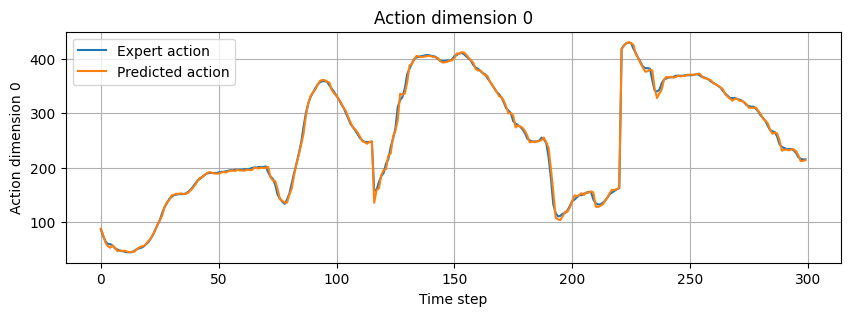

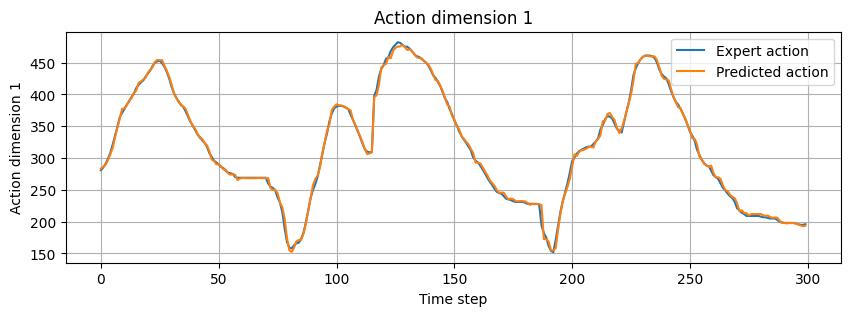

,epoch,train_loss,val_loss,val_mae,val_mse
0,1,0.024235,0.005839,4.674605,56.449764
1,2,0.004907,0.004469,4.173030,43.197041
2,3,0.004180,0.003846,3.766270,37.295567
3,4,0.003709,0.004304,4.297366,41.846058
4,5,0.003752,0.003317,3.389738,32.137978
5,6,0.003583,0.003701,3.782698,35.653397
6,7,0.003766,0.003819,3.927245,37.155857
7,8,0.003585,0.003732,3.816137,35.957066
8,9,0.003612,0.003572,3.683278,34.571041
9,10,0.003484,0.003325,3.433322,32.113018


State dim: 18
Action dim: 2


Training:   0%|          | 0/308 [00:00<?, ?it/s]

running loss at step 0 : 1.0871198177337646
running loss at step 100 : 0.0627301431878811
running loss at step 200 : 0.03558339695075517
running loss at step 300 : 0.025952478586866265


Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

...

running loss at step 0 : 0.0029345392249524593
running loss at step 100 : 0.003464168648807203
running loss at step 200 : 0.0034938232251558806
running loss at step 300 : 0.0034573808884050114


Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 10 | train_loss=0.0035 | val_loss=0.0037 | val_mae=3.8825 | val_mse=36.3463


Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

,action_dim,mae,relative_mae
0,0,4.340811,0.042357
1,1,3.424100,0.036164


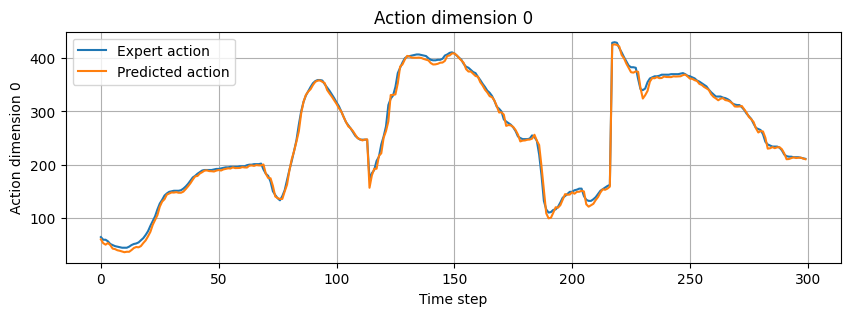

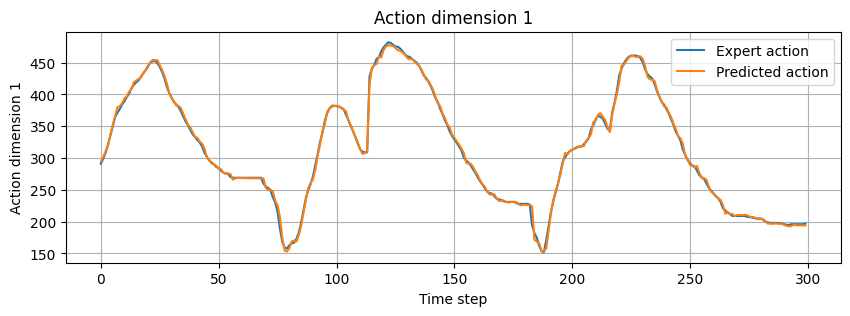

,epoch,train_loss,val_loss,val_mae,val_mse
0,1,0.025470,0.006234,4.854040,60.330704
1,2,0.005255,0.004786,4.237909,46.327332
2,3,0.004395,0.004484,4.233909,43.424126
3,4,0.004096,0.004428,4.235941,42.880032
4,5,0.003937,0.004591,4.510171,44.405258
5,6,0.003974,0.004286,4.239323,41.323528
6,7,0.003696,0.003769,3.795512,36.689064
7,8,0.003553,0.003799,3.912193,36.835140
8,9,0.003584,0.003817,3.855113,36.944405
9,10,0.003460,0.003735,3.882452,36.346313


State dim: 34
Action dim: 2


Training:   0%|          | 0/298 [00:00<?, ?it/s]

running loss at step 0 : 0.9852554798126221
running loss at step 100 : 0.068608170421333
running loss at step 200 : 0.04034855743564332


Evaluating:   0%|          | 0/78 [00:00<?, ?it/s]

...

running loss at step 0 : 0.0023371465504169464
running loss at step 100 : 0.00343787488827279
running loss at step 200 : 0.003828538658759969


Evaluating:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch 10 | train_loss=0.0038 | val_loss=0.0039 | val_mae=4.1027 | val_mse=37.4876


Evaluating:   0%|          | 0/78 [00:00<?, ?it/s]

,action_dim,mae,relative_mae
0,0,3.935771,0.038495
1,1,4.269644,0.045618


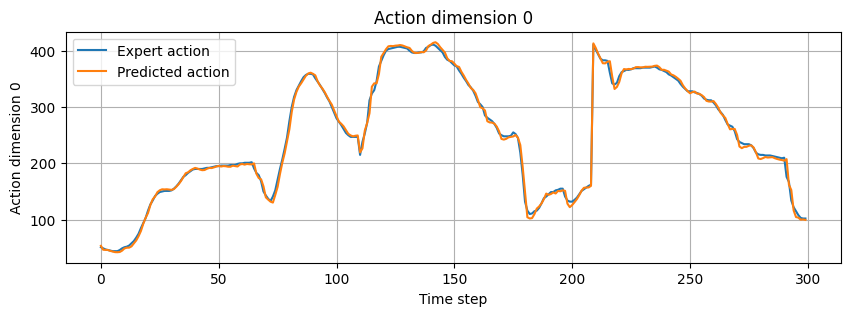

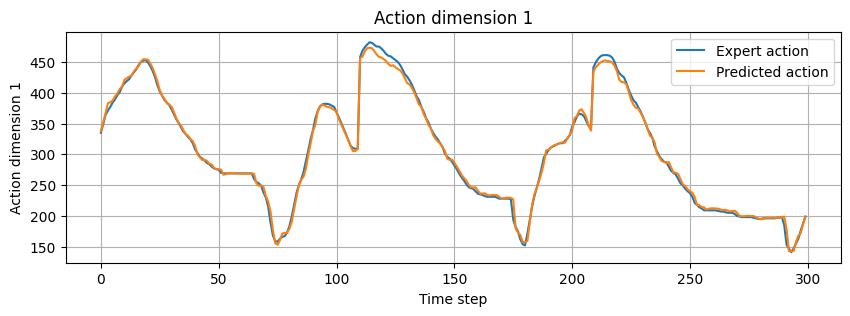

,epoch,train_loss,val_loss,val_mae,val_mse
0,1,0.030060,0.008380,6.148979,81.473694
1,2,0.006267,0.007904,6.180175,74.902077
2,3,0.005173,0.005594,5.096279,54.649731
3,4,0.004502,0.004026,4.007586,39.000504
4,5,0.004231,0.004418,4.425187,42.761074
5,6,0.004045,0.004744,4.762626,45.915108
6,7,0.003846,0.003648,3.847071,35.421501
7,8,0.003633,0.005712,5.321604,56.008522
8,9,0.003752,0.003860,4.070517,37.364765
9,10,0.003765,0.003895,4.102708,37.487598


In [ ]:
K = [2,4,8]
prevk_histories_df = {}

for k in K:
  train_prevk_ds = StatePrevKActionDataset(
      dataset,
      train_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  val_prevk_ds = StatePrevKActionDataset(
      dataset,
      val_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  sample_batch = train_prevk_ds[0]
  state_dim = sample_batch["state_norm"].numel()
  action_dim = sample_batch["action"].numel()

  print("State dim:", state_dim)
  print("Action dim:", action_dim)

  prevk_train_dataloader = DataLoader(
      train_prevk_ds,
      batch_size=64,
      shuffle=True,
  )

  prevk_val_dataloader = DataLoader(
      val_prevk_ds,
      batch_size=64,
      shuffle=False,
  )

  prevk_model = MLP_head(
      state_dim=state_dim,
      action_dim=action_dim,
      hidden_dim=256,
  ).to(device)

  optimizer = torch.optim.AdamW(
      prevk_model.parameters(),
      lr=1e-3,
      weight_decay=1e-4,
  )

  history = []

  NUM_EPOCHS = 10

  for epoch in range(NUM_EPOCHS):
      train_loss = train_one_epoch(
          prevk_model,
          optimizer,
          prevk_train_dataloader,
          device,
      )

      val_metrics = evaluate_model(
          prevk_model,
          prevk_val_dataloader,
          train_prevk_ds.train_action_mean,
          train_prevk_ds.train_action_std,
          device,
      )

      row = {
          "epoch": epoch + 1,
          "train_loss": train_loss,
          "val_loss": val_metrics["loss"],
          "val_mae": val_metrics["mae"],
          "val_mse": val_metrics["mse"],
      }

      history.append(row)

      print(
          f"Epoch {epoch+1:02d} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"val_mae={val_metrics['mae']:.4f} | "
          f"val_mse={val_metrics['mse']:.4f}"
      )

  final_per_dim_val_metrics = evaluate_model(
      prevk_model,
      prevk_val_dataloader,
      train_prevk_ds.train_action_mean,
      train_prevk_ds.train_action_std,
      device
  )

  display(final_per_dim_val_metrics["per_dim_metrics"])
  plot_action_trajectory(final_per_dim_val_metrics["y_true"], final_per_dim_val_metrics["y_pred"])

  prevk_histories_df[k] = pd.DataFrame(history)
  display(prevk_histories_df[k])

# GRU Policy

In [ ]:
class GRUDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, episode_key, train_actions, train_states, k=2):
    self.dataset = dataset
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = train_actions
    self.train_states = train_states
    self.k = k
    self.indices = [int(idx) for idx in list(indices) if self._same_episode(int(idx))]

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

    self.train_state_mean = torch.from_numpy(self.train_states.mean(axis=0)).float()
    self.train_state_std = torch.from_numpy(self.train_states.std(axis=0) + 1e-6).float()


  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx-self.k < 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample_k = self.dataset[idx-self.k][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample_k, torch.Tensor):
      previous_sample_k = int(previous_sample_k.item())
    else:
      previous_sample_k = int(previous_sample_k)

    return current_sample == previous_sample_k

  def __getitem__(self, i):
    idx = self.indices[i]
    sample = self.dataset[idx]

    state = to_float_tensor(sample[self.state_key]).reshape(-1)
    action = to_float_tensor(sample[self.action_key]).reshape(-1)

    action_norm = (action - self.train_action_mean) / self.train_action_std
    state_norm = (state - self.train_state_mean) / self.train_state_std

    # Current state/action pairs
    # [state_(t), zeros, action not available]
    current_token = torch.cat([state_norm, torch.zeros_like(action_norm), torch.tensor([0.0])], dim=0)

    sequence = []


    # -----------------------------------------
    # Historical state/action pairs
    #
    # [state_(t-k), action_(t-k), action available]
    # ...
    # [state_(t-1), action_(t-1), action available]
    # -----------------------------------------
    for offset in range(self.k, 0, -1):
      previous_action_k = to_float_tensor(self.dataset[idx-offset][self.action_key]).reshape(-1)
      previous_action_k_norm = (previous_action_k - self.train_action_mean) / self.train_action_std

      previous_state_k = to_float_tensor(self.dataset[idx-offset][self.state_key]).reshape(-1)
      previous_state_k_norm = (previous_state_k - self.train_state_mean) / self.train_state_std

      token = torch.cat([previous_state_k_norm, previous_action_k_norm, torch.tensor([1.0])], dim=0)
      sequence.append(token)

    sequence.append(current_token)
    sequence = torch.stack(sequence, dim=0)

    return {
        "action": action,
        "action_norm": action_norm,
        "state_norm": sequence,
        "dataset_index": idx
    }

In [ ]:
class GRUActionPolicy(nn.Module):
    def __init__(
        self,
        input_dim,
        action_dim,
        hidden_dim=256,
        num_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.action_head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, sequence_norm):
        output, hidden = self.gru(sequence_norm)
        last_hidden = output[:, -1, :]
        action_norm = self.action_head(last_hidden)
        return action_norm

State dim: 5
Action dim: 2
input: torch.Size([64, 3, 5])
prediction: torch.Size([64, 2])


Training:   0%|          | 0/313 [00:00<?, ?it/s]

running loss at step 0 : 1.1296671628952026
running loss at step 100 : 0.059353719502318616
running loss at step 200 : 0.038126738084044626
running loss at step 300 : 0.030683246453561856


Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.0301 | val_loss=0.0147 | val_mae=8.5778 | val_mse=141.0652


...

running loss at step 0 : 0.010147151537239552
running loss at step 100 : 0.007195632547453636
running loss at step 200 : 0.00684445587436284
running loss at step 300 : 0.006912076212249176


Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 10 | train_loss=0.0069 | val_loss=0.0052 | val_mae=4.9009 | val_mse=50.8276


Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

,action_dim,mae,relative_mae
0,0,5.363356,0.052274
1,1,4.438519,0.046537


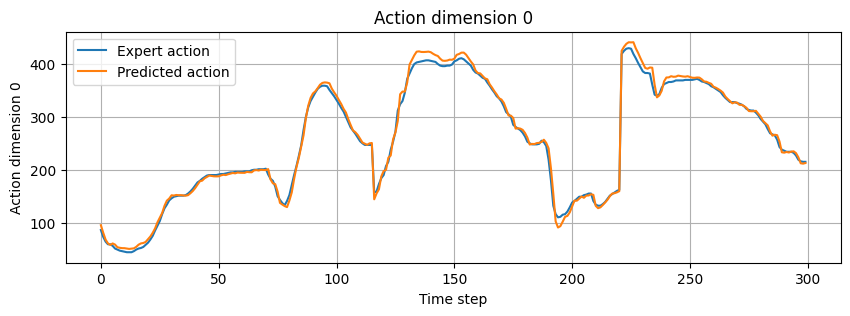

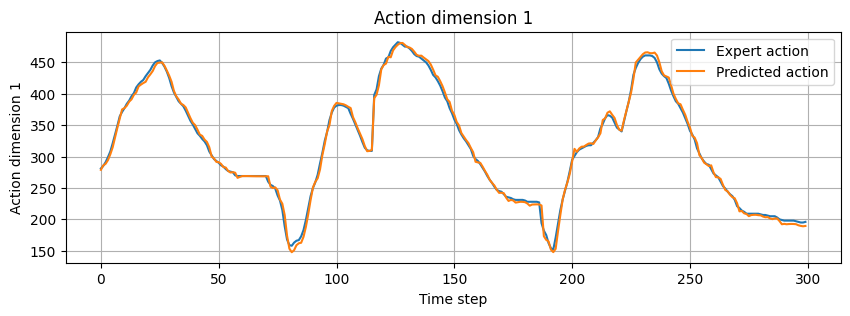

,epoch,train_loss,val_loss,val_mae,val_mse
0,1,0.030105,0.014651,8.577823,141.065201
1,2,0.014486,0.013130,8.185206,127.209343
2,3,0.013191,0.011329,7.287074,108.316879
3,4,0.012384,0.012478,8.001167,120.570137
4,5,0.011233,0.014502,9.229991,140.243561
5,6,0.010389,0.007249,5.703172,70.343941
6,7,0.009073,0.006609,5.523821,63.606998
7,8,0.008339,0.005449,4.797679,52.475372
8,9,0.007334,0.005619,5.205977,54.577164
9,10,0.006905,0.005222,4.900935,50.827641


State dim: 5
Action dim: 2
input: torch.Size([64, 5, 5])
prediction: torch.Size([64, 2])


Training:   0%|          | 0/308 [00:00<?, ?it/s]

running loss at step 0 : 1.3250035047531128
running loss at step 100 : 0.06980852351182758
running loss at step 200 : 0.04680046249199566
running loss at step 300 : 0.038108221286183776


Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

...

running loss at step 0 : 0.005678236018866301
running loss at step 100 : 0.00545794591261535
running loss at step 200 : 0.005651456354862422
running loss at step 300 : 0.005805673101681758


Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 10 | train_loss=0.0058 | val_loss=0.0041 | val_mae=4.1568 | val_mse=39.6800


Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

,action_dim,mae,relative_mae
0,0,4.756806,0.046416
1,1,3.556726,0.037565


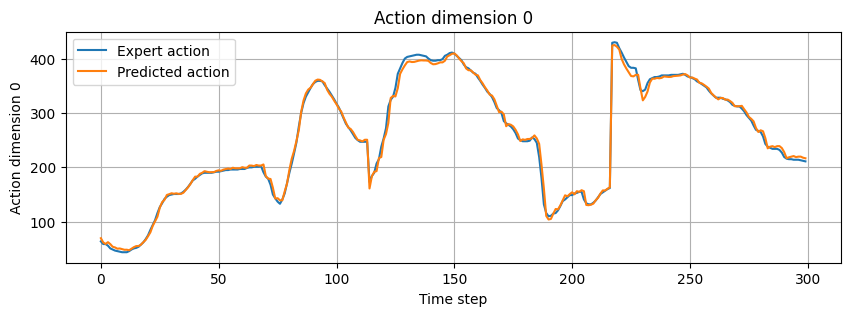

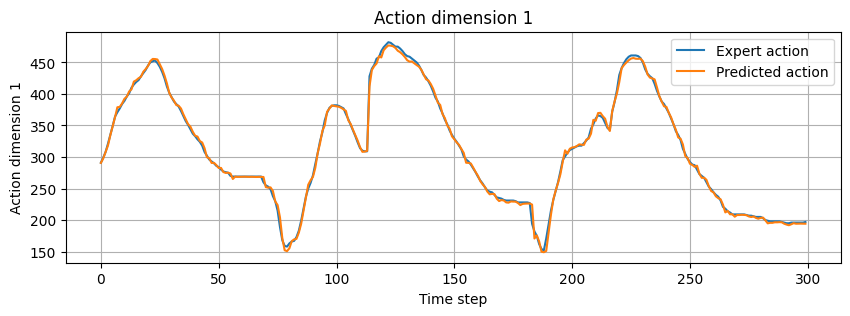

,epoch,train_loss,val_loss,val_mae,val_mse
0,1,0.037696,0.016404,8.930483,158.125809
1,2,0.015876,0.010992,7.442341,106.950043
2,3,0.011315,0.009551,6.806934,92.017105
3,4,0.009500,0.007637,6.290133,74.383247
4,5,0.007740,0.004338,4.188715,41.922848
5,6,0.007374,0.007506,6.200271,73.891388
6,7,0.007104,0.005754,5.378979,55.727741
7,8,0.006352,0.007439,6.576124,71.152237
8,9,0.006062,0.006469,5.576097,61.550667
9,10,0.005795,0.004070,4.156764,39.680046


State dim: 5
Action dim: 2
input: torch.Size([64, 9, 5])
prediction: torch.Size([64, 2])


Training:   0%|          | 0/298 [00:00<?, ?it/s]

running loss at step 0 : 1.0765187740325928
running loss at step 100 : 0.07205731073154671
running loss at step 200 : 0.04610199713847827


Evaluating:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.0363 | val_loss=0.0173 | val_mae=9.5261 | val_mse=165.9085


Training:   0%|          | 0/298 [00:00<?, ?it/s]

running loss at step 0 : 0.025380128994584084
running loss at step 100 : 0.013991163919062013
running loss at step 200 : 0.0130551225825477


Evaluating:   0%|          | 0/78 [00:00<?, ?it/s]

In [ ]:
K = [2,4,8]
gru_histories_df = {}

for k in K:
  train_gru_ds = GRUDataset(
      dataset,
      train_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  val_gru_ds = GRUDataset(
      dataset,
      val_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  sample_batch = train_gru_ds[0]
  state_dim = sample_batch["state_norm"].shape[1]
  action_dim = sample_batch["action_norm"].numel()

  print("State dim:", state_dim)
  print("Action dim:", action_dim)

  gru_train_dataloader = DataLoader(
      train_gru_ds,
      batch_size=64,
      shuffle=True,
  )

  gru_val_dataloader = DataLoader(
      val_gru_ds,
      batch_size=64,
      shuffle=False,
  )

  gru_model = GRUActionPolicy(
    input_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=256,
    num_layers=3,
    dropout=0.2,
  ).to(device)

  optimizer = torch.optim.AdamW(
      gru_model.parameters(),
      lr=1e-3,
      weight_decay=1e-4,
  )

  sample_batch = next(iter(gru_train_dataloader))
  x = sample_batch["state_norm"].to(device)

  with torch.no_grad():
      pred = gru_model(x)

  print("input:", x.shape)
  print("prediction:", pred.shape)

  history = []

  NUM_EPOCHS = 10

  for epoch in range(NUM_EPOCHS):
      train_loss = train_one_epoch(
          gru_model,
          optimizer,
          gru_train_dataloader,
          device,
      )

      val_metrics = evaluate_model(
          gru_model,
          gru_val_dataloader,
          train_gru_ds.train_action_mean,
          train_gru_ds.train_action_std,
          device,
      )

      row = {
          "epoch": epoch + 1,
          "train_loss": train_loss,
          "val_loss": val_metrics["loss"],
          "val_mae": val_metrics["mae"],
          "val_mse": val_metrics["mse"],
      }

      history.append(row)

      print(
          f"Epoch {epoch+1:02d} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"val_mae={val_metrics['mae']:.4f} | "
          f"val_mse={val_metrics['mse']:.4f}"
      )

  final_per_dim_val_metrics = evaluate_model(
    gru_model,
    gru_val_dataloader,
    train_gru_ds.train_action_mean,
    train_gru_ds.train_action_std,
    device
    )

  display(final_per_dim_val_metrics["per_dim_metrics"])
  plot_action_trajectory(final_per_dim_val_metrics["y_true"], final_per_dim_val_metrics["y_pred"])

  gru_histories_df[k] = pd.DataFrame(history)
  display(gru_histories_df[k])

# Image Action Prediction

In [ ]:
class ImageActionDataset(Dataset):
  def __init__(self, dataset, indices, image_key, action_key, train_actions):
    self.dataset = dataset
    self.indices = indices
    self.image_key = image_key
    self.action_key = action_key
    self.train_actions = train_actions

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

  def __len__(self):
    return len(self.indices)

  def __getitem__(self, i):
    idx = self.indices[i]
    sample = self.dataset[idx]

    action = to_float_tensor(sample[self.action_key]).reshape(-1)
    image = to_float_tensor(sample[self.image_key])

    action_norm = (action - self.train_action_mean) / self.train_action_std
    image_norm = image/255.0 if image.max() > 2.0 else image

    return {
        "image": image,
        "action": action,
        "image_norm": image_norm,
        "action_norm": action_norm,
        "dataset_index": idx
    }

In [ ]:
class CNNModel(nn.Module):
  def __init__(self, action_dim):
    super().__init__()

    self.backbone = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),

        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),

        nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),

        nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU()
    )

    self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 256 * 2 * 2),
            nn.ReLU(),
            nn.Linear(256 * 2 * 2, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim),
        )

  def forward(self, image):
    encoded = self.backbone(image)
    return self.head(encoded)

In [ ]:
def train_one_epoch_image(model, optimizer, train_dataloader, device):
  model.train()
  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
    image_norm = batch["image_norm"].to(device)
    action_norm = batch["action_norm"].to(device)

    action_pred = model(image_norm)
    loss = F.mse_loss(action_pred, action_norm)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_size = action_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    if step%100 == 0:
      print("running loss at step", step, ":", running_loss / max(total_count, 1))

  return running_loss / max(total_count, 1)

@torch.no_grad()
def evaluate_model_image(model, val_dataloader, action_mean, action_std, device):
  model.eval()

  action_mean = action_mean.to(device)
  action_std = action_std.to(device)

  all_true = []
  all_pred = []

  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(val_dataloader, desc="Evaluating")):
    image_norm = batch["image_norm"].to(device)
    action_norm = batch["action_norm"].to(device)
    action = batch["action"].to(device)

    action_pred_norm = model(image_norm)
    loss = F.mse_loss(action_pred_norm, action_norm)

    batch_size = action_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    unnorm_action_pred = action_pred_norm * action_std + action_mean
    all_true.append(action.cpu().numpy())
    all_pred.append(unnorm_action_pred.cpu().numpy())

  all_true = np.concatenate(all_true, axis=0)
  all_pred = np.concatenate(all_pred, axis=0)

  mae = np.mean(np.abs(all_true - all_pred))
  mse = np.mean((all_true - all_pred)**2)

  per_dim_metrics = per_action_dim_metrics(all_true, all_pred)

  return {
        "loss": running_loss / max(total_count, 1),
        "mae": mae,
        "mse": mse,
        "per_dim_metrics": per_dim_metrics,
        "y_true": all_true,
        "y_pred": all_pred
  }

In [ ]:
train_image_ds = ImageActionDataset(
        dataset,
        train_indices,
        image_key,
        action_key,
        train_actions
    )

val_image_ds = ImageActionDataset(
    dataset,
    val_indices,
    image_key,
    action_key,
    train_actions
)

sample_batch = train_image_ds[0]
action_dim = sample_batch["action"].numel()

image_train_loader = DataLoader(train_image_ds, batch_size=64, shuffle=True)
image_val_loader = DataLoader(val_image_ds, batch_size=64, shuffle=False)

image_model = CNNModel(action_dim=action_dim).to(device)

optimizer = torch.optim.AdamW(image_model.parameters(), lr=1e-3, weight_decay=1e-4)

image_history = []

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch_image(
        image_model,
        optimizer,
        image_train_loader,
        device,
    )

    val_metrics = evaluate_model_image(
        image_model,
        image_val_loader,
        train_image_ds.train_action_mean,
        train_image_ds.train_action_std,
        device,
    )

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_mae": val_metrics["mae"],
        "val_mse": val_metrics["mse"],
    }

    image_history.append(row)

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_mae={val_metrics['mae']:.4f}"
        f"val_mse={val_metrics['mse']:.4f}"
    )

final_val_metrics = evaluate_model_image(
    image_model,
    image_val_loader,
    train_image_ds.train_action_mean,
    train_image_ds.train_action_std,
    device
)

display(final_val_metrics["per_dim_metrics"])
plot_action_trajectory(final_val_metrics["y_true"], final_val_metrics["y_pred"])

image_history_df = pd.DataFrame(image_history)
display(image_history_df)

# Image State Previous K Action Prediction

In [ ]:
class ImagekPrevActionDataset(Dataset):
  def __init__(self, dataset, indices, image_key, state_key, action_key, episode_key, train_actions, train_states, k):
    self.dataset = dataset
    self.image_key = image_key
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = train_actions
    self.train_states = train_states
    self.k = k
    self.indices = [int(idx) for idx in list(indices) if self._same_episode(int(idx))]

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

    self.train_state_mean = torch.from_numpy(self.train_states.mean(axis=0)).float()
    self.train_state_std = torch.from_numpy(self.train_states.std(axis=0) + 1e-6).float()


  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx-self.k < 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample_k = self.dataset[idx-self.k][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample_k, torch.Tensor):
      previous_sample_k = int(previous_sample_k.item())
    else:
      previous_sample_k = int(previous_sample_k)

    return current_sample == previous_sample_k

  def __getitem__(self, i):
    idx = self.indices[i]
    sample = self.dataset[idx]

    state = to_float_tensor(sample[self.state_key]).reshape(-1)
    action = to_float_tensor(sample[self.action_key]).reshape(-1)

    action_norm = (action - self.train_action_mean) / self.train_action_std
    state_norm = (state - self.train_state_mean) / self.train_state_std

    # Current state/action pairs
    # [state_(t), zeros, action not available]
    current_token = torch.cat([state_norm, torch.zeros_like(action_norm), torch.tensor([0.0])], dim=0)

    sequence = []

    # -----------------------------------------
    # Historical state/action pairs
    #
    # [state_(t-k), action_(t-k), action available]
    # ...
    # [state_(t-1), action_(t-1), action available]
    # -----------------------------------------
    for offset in range(self.k, 0, -1):
      previous_action_k = to_float_tensor(self.dataset[idx-offset][self.action_key]).reshape(-1)
      previous_action_k_norm = (previous_action_k - self.train_action_mean) / self.train_action_std

      previous_state_k = to_float_tensor(self.dataset[idx-offset][self.state_key]).reshape(-1)
      previous_state_k_norm = (previous_state_k - self.train_state_mean) / self.train_state_std

      token = torch.cat([previous_state_k_norm, previous_action_k_norm, torch.tensor([1.0])], dim=0)
      sequence.append(token)

    sequence.append(current_token)
    sequence = torch.stack(sequence, dim=0)

    image = to_float_tensor(sample[self.image_key])
    image_norm = image/255.0 if image.max() > 2.0 else image

    return {
        "image": image,
        "action": action,
        "image_norm": image_norm,
        "state_norm": sequence,
        "action_norm": action_norm,
        "dataset_index": idx
    }

In [ ]:
class kActionImageEncoder(nn.Module):
  def __init__(self, backbone_name = "convnext_tiny", embedding_dim=256, freeze_backbone=True):
    super().__init__()

    self.backbone_name = backbone_name
    self.freeze_backbone = freeze_backbone

    if backbone_name == "resnet50":
        weights = ResNet50_Weights.IMAGENET1K_V2
        model = resnet50(weights=weights)

        feature_dim = model.fc.in_features
        model.fc = nn.Identity()

        self.backbone = model

    elif backbone_name == "convnext_tiny":
        weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        model = convnext_tiny(weights=weights)

        feature_dim = model.classifier[-1].in_features

        self.backbone = nn.Sequential(
            model.features,
            model.avgpool,
            nn.Flatten(1),
        )

    else:
        raise ValueError(
            f"Unknown backbone: {backbone_name}. "
            "Use 'resnet50' or 'convnext_tiny'."
        )

    if self.freeze_backbone:
      for param in self.backbone.parameters():
          param.requires_grad = False

    self.head = nn.Sequential(
        nn.Linear(feature_dim, 512),
        nn.ReLU(),
        nn.Linear(512, embedding_dim),
        )

  def forward(self, image):
    if self.freeze_backbone:
        self.backbone.eval()

        with torch.no_grad():
            encoded = self.backbone(image)
    else:
        encoded = self.backbone(image)
    return self.head(encoded)

In [ ]:
class GRUEncoder(nn.Module):
    def __init__(
        self,
        input_dim,
        embedding_dim=256,
        hidden_dim=256,
        num_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.projection = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, embedding_dim),
            nn.ReLU(),
        )

    def forward(self, sequence_norm):
        _, hidden = self.gru(sequence_norm)
        last_hidden = hidden[-1]
        embedding = self.projection(last_hidden)
        return embedding

In [ ]:
class FusionMLP(nn.Module):
  def __init__(self, input_dim, action_dim, hidden_dim=512):
    super().__init__()
    self.input_dim = input_dim
    self.action_dim = action_dim
    self.hidden_dim = hidden_dim

    self.mlp = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, action_dim),
    )

  def forward(self, input_bundle):
    return self.mlp(input_bundle)

In [ ]:
def train_one_epoch_image_kprev(image_model, gru_model, fusion_head, optimizer, train_dataloader, device):
  image_model.train()
  gru_model.train()
  fusion_head.train()
  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
    image_norm = batch["image_norm"].to(device)
    state_norm = batch["state_norm"].to(device)
    action_norm = batch["action_norm"].to(device)

    image_embedding = image_model(image_norm)
    state_embedding = gru_model(state_norm)

    input_bundle = torch.cat([image_embedding, state_embedding], dim=1)
    action_pred = fusion_head(input_bundle)
    loss = F.mse_loss(action_pred, action_norm)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_size = action_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    if step%100 == 0:
      print("running loss at step", step, ":", running_loss / max(total_count, 1))

  return running_loss / max(total_count, 1)

@torch.no_grad()
def evaluate_model_image_kprev(image_model, gru_model, fusion_head, val_dataloader, action_mean, action_std, device):
  image_model.eval()
  gru_model.eval()
  fusion_head.eval()

  action_mean = action_mean.to(device)
  action_std = action_std.to(device)

  all_true = []
  all_pred = []

  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(val_dataloader, desc="Evaluating")):
    image_norm = batch["image_norm"].to(device)
    state_norm = batch["state_norm"].to(device)
    action_norm = batch["action_norm"].to(device)
    action = batch["action"].to(device)

    image_embedding = image_model(image_norm)
    state_embedding = gru_model(state_norm)

    input_bundle = torch.cat([image_embedding, state_embedding], dim=1)
    action_pred_norm = fusion_head(input_bundle)
    loss = F.mse_loss(action_pred_norm, action_norm)

    batch_size = action_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    unnorm_action_pred = action_pred_norm * action_std + action_mean
    all_true.append(action.cpu().numpy())
    all_pred.append(unnorm_action_pred.cpu().numpy())

  all_true = np.concatenate(all_true, axis=0)
  all_pred = np.concatenate(all_pred, axis=0)

  mae = np.mean(np.abs(all_true - all_pred))
  mse = np.mean((all_true - all_pred)**2)

  per_dim_metrics = per_action_dim_metrics(all_true, all_pred)

  return {
        "loss": running_loss / max(total_count, 1),
        "mae": mae,
        "mse": mse,
        "per_dim_metrics": per_dim_metrics,
        "y_true": all_true,
        "y_pred": all_pred
  }

In [ ]:
K = [2,4,8]
image_kprev_action_histories_df = {}
BACKBONE_NAME = "resnet50"
embedding_dim = 256
BATCH_NUMBER = 64

for k in K:
  train_kprev_image_ds = ImagekPrevActionDataset(
          dataset,
          train_indices,
          image_key,
          state_key,
          action_key,
          episode_key,
          train_actions,
          train_states,
          k
      )

  val_kprev_image_ds = ImagekPrevActionDataset(
      dataset,
      val_indices,
      image_key,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k
  )

  sample_batch = train_kprev_image_ds[0]
  state_dim = sample_batch["state_norm"].shape[-1]
  action_dim = sample_batch["action"].numel()

  print(f"state_dim: {state_dim}")
  print(f"action_dim: {action_dim}")

  image_kprev_train_loader = DataLoader(train_kprev_image_ds, batch_size=BATCH_NUMBER, shuffle=True)
  image_kprev_val_loader = DataLoader(val_kprev_image_ds, batch_size=BATCH_NUMBER, shuffle=False)

  image_model = kActionImageEncoder(backbone_name=BACKBONE_NAME, embedding_dim=embedding_dim).to(device)
  gru_model = GRUEncoder(state_dim, hidden_dim=embedding_dim).to(device)
  fusion_head = FusionMLP(input_dim = 512, action_dim=action_dim).to(device)

  optimizer = torch.optim.AdamW(
      list(image_model.parameters()) +
      list(gru_model.parameters()) +
      list(fusion_head.parameters()),
      lr=1e-3,
      weight_decay=1e-4,
  )

  image_kprev_action_history = []

  NUM_EPOCHS = 10

  for epoch in range(NUM_EPOCHS):
      train_loss = train_one_epoch_image_kprev(
          image_model,
          gru_model,
          fusion_head,
          optimizer,
          image_kprev_train_loader,
          device,
      )

      val_metrics = evaluate_model_image_kprev(
          image_model,
          gru_model,
          fusion_head,
          image_kprev_val_loader,
          train_kprev_image_ds.train_action_mean,
          train_kprev_image_ds.train_action_std,
          device,
      )

      row = {
          "epoch": epoch + 1,
          "train_loss": train_loss,
          "val_loss": val_metrics["loss"],
          "val_mae": val_metrics["mae"],
          "val_mse": val_metrics["mse"],
      }

      image_kprev_action_history.append(row)

      print(
          f"Epoch {epoch+1:02d} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"val_mae={val_metrics['mae']:.4f}"
          f"val_mse={val_metrics['mse']:.4f}"
      )

  final_val_metrics = evaluate_model_image_kprev(
      image_model,
      gru_model,
      fusion_head,
      image_kprev_val_loader,
      train_kprev_image_ds.train_action_mean,
      train_kprev_image_ds.train_action_std,
      device
  )

  display(final_val_metrics["per_dim_metrics"])
  plot_action_trajectory(final_val_metrics["y_true"], final_val_metrics["y_pred"])

  image_kprev_action_histories_df[k] = pd.DataFrame(image_kprev_action_history)
  display(image_kprev_action_histories_df[k])

In [ ]:
baseline_rows = []

baseline_rows.append({
    "model": "Mean Action",
    "val_mae": mean_baseline["mae"],
    "val_mse": mean_baseline["mse"],
})

baseline_rows.append({
    "model": "Previous Action",
    "val_mae": prev_baseline["mae"],
    "val_mse": prev_baseline["mse"],
})

if "state_history_df" in globals():
    final_state_row = best_row(state_history_df)

    baseline_rows.append({
        "model": "State -> Action MLP",
        "val_mae": float(final_state_row["val_mae"]),
        "val_mse": float(final_state_row["val_mse"]),
    })

if "prevaction_history_df" in globals():
    final_prevaction_row = best_row(prevaction_history_df)

    baseline_rows.append({
        "model": "State + Prev Action -> Action MLP",
        "val_mae": float(final_prevaction_row["val_mae"]),
        "val_mse": float(final_prevaction_row["val_mse"]),
    })

if "image_history_df" in globals():
    final_image_row = best_row(image_history_df)

    baseline_rows.append({
        "model": "Image -> Action CNN",
        "val_mae": float(final_image_row["val_mae"]),
        "val_mse": float(final_image_row["val_mse"]),
    })

if "prevk_histories_df" in globals():
  for k, prevk_history_df in prevk_histories_df.items():
    final_prevk_row = best_row(prevk_history_df)

    baseline_rows.append({
        "model": f"State + {k} Prev States + {k} Prev Actions -> Action MLP",
        "val_mae": float(final_prevk_row["val_mae"]),
        "val_mse": float(final_prevk_row["val_mse"]),
      })

if "image_kprev_action_histories" in globals():
  for k, image_kprev_action_history_df in image_kprev_action_histories_df.items():
    final_image_kprev_row = best_row(image_kprev_action_history_df)

    baseline_rows.append({
        "model": f"Image + {k} State + {k} Previous Action -> Action MLP",
        "val_mae": float(final_image_kprev_row["val_mae"]),
        "val_mse": float(final_image_kprev_row["val_mse"]),
    })

baseline_comparison_df = pd.DataFrame(baseline_rows)
display(baseline_comparison_df.sort_values("val_mae"))

#pretrained VLA model: SmolVLA

In [28]:
import lerobot
!pip install -q "lerobot[smolvla]"

print("LeRobot version:", lerobot.__version__)

LeRobot version: 0.6.1


In [20]:
def scalar_int(x):
    if isinstance(x, torch.Tensor):
        return int(x.item())
    return int(x)


train_episode_ids = sorted({
    scalar_int(dataset[int(idx)][episode_key])
    for idx in train_indices
})

val_episode_ids = sorted({
    scalar_int(dataset[int(idx)][episode_key])
    for idx in val_indices
})

print("Train episodes:", len(train_episode_ids))
print("Val episodes:", len(val_episode_ids))
print("First train episodes:", train_episode_ids[:10])
print("First val episodes:", val_episode_ids[:10])

Train episodes: 164
Val episodes: 42
First train episodes: [0, 2, 3, 4, 5, 6, 7, 8, 9, 10]
First val episodes: [1, 14, 20, 21, 37, 48, 50, 52, 54, 57]


In [22]:
DATASET_REPO_ID = dataset.repo_id

TRAIN_EPISODES_ARG = "[" + ",".join(
    str(x) for x in train_episode_ids
) + "]"

print(DATASET_REPO_ID)
print(TRAIN_EPISODES_ARG[:300], "...")
print(val_episode_ids)

lerobot/pusht
[0,2,3,4,5,6,7,8,9,10,11,12,13,15,16,17,18,19,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,38,39,40,41,42,43,44,45,46,47,49,51,53,55,56,59,60,61,62,64,65,66,67,68,69,70,73,75,76,77,78,79,80,81,82,83,84,85,86,89,90,91,93,94,95,96,97,98,100,101,104,105,108,109,110,111,112,113,114,115,117,118,119,120,1 ...
[1, 14, 20, 21, 37, 48, 50, 52, 54, 57, 58, 63, 71, 72, 74, 87, 88, 92, 99, 102, 103, 106, 107, 116, 121, 129, 130, 134, 149, 151, 157, 160, 169, 172, 179, 181, 188, 189, 194, 198, 202, 205]


In [37]:
import subprocess
# from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy

OUTPUT_DIR = "/content/smolvla_pusht_smoke"
!rm -r $OUTPUT_DIR
# model_id = "lerobot/smolvla_base"
# model_policy = SmolVLAPolicy.from_pretrained(model_id).to(device).eval()

cmd = [
    "lerobot-train",

    "--policy.path=lerobot/smolvla_base",
    "--policy.load_vlm_weights=true",
    "--policy.freeze_vision_encoder=true",
    "--policy.train_expert_only=true",

    "--policy.chunk_size=10",
    "--policy.n_action_steps=10",

    "--policy.device=cuda",
    "--policy.push_to_hub=false",

    f"--dataset.repo_id={DATASET_REPO_ID}",
    f"--dataset.episodes={TRAIN_EPISODES_ARG}",
    '--rename_map={"observation.image":"observation.images.camera1"}',

    "--batch_size=4",
    "--steps=100",

    "--save_freq=100",
    "--save_checkpoint=true",

    "--wandb.enable=false",

    f"--output_dir={OUTPUT_DIR}",
]

result = subprocess.run(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print(result.stdout)
print("\nReturn code:", result.returncode)

rm: cannot remove '/content/smolvla_pusht_smoke': No such file or directory
INFO 2026-09-03 01:16:13 ot_train.py:272 {'batch_size': 4,
 'checkpoint_path': None,
 'cudnn_deterministic': False,
 'dataloader_multiprocessing_context': 'spawn',
 'dataset': {'depth_output_unit': 'mm',
             'episodes': [0,
                          2,
                          3,
                          4,
                          5,
                          6,
                          7,
                          8,
                          9,
                          10,
                          11,
                          12,
                          13,
                          15,
                          16,
                          17,
                          18,
                          19,
                          22,
                          23,
                          24,
                          25,
                          26,
                          27,
         

In [38]:
OUTPUT_DIR = "/content/smolvla_pusht"

cmd = [
    "lerobot-train",

    "--policy.path=lerobot/smolvla_base",
    "--policy.load_vlm_weights=true",
    "--policy.freeze_vision_encoder=true",
    "--policy.train_expert_only=true",

    "--policy.chunk_size=10",
    "--policy.n_action_steps=10",

    "--policy.device=cuda",
    "--policy.push_to_hub=false",

    f"--dataset.repo_id={DATASET_REPO_ID}",
    f"--dataset.episodes={TRAIN_EPISODES_ARG}",
    '--rename_map={"observation.image":"observation.images.camera1"}',

    "--batch_size=4",

    # Good first real experiment.
    "--steps=5000",

    "--save_freq=1000",
    "--save_checkpoint=true",

    "--log_freq=50",
    "--wandb.enable=false",

    f"--output_dir={OUTPUT_DIR}",
]

subprocess.run(cmd, check=True)

CompletedProcess(args=['lerobot-train', '--policy.path=lerobot/smolvla_base', '--policy.load_vlm_weights=true', '--policy.freeze_vision_encoder=true', '--policy.train_expert_only=true', '--policy.chunk_size=10', '--policy.n_action_steps=10', '--policy.device=cuda', '--policy.push_to_hub=false', '--dataset.repo_id=lerobot/pusht', '--dataset.episodes=[0,2,3,4,5,6,7,8,9,10,11,12,13,15,16,17,18,19,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,38,39,40,41,42,43,44,45,46,47,49,51,53,55,56,59,60,61,62,64,65,66,67,68,69,70,73,75,76,77,78,79,80,81,82,83,84,85,86,89,90,91,93,94,95,96,97,98,100,101,104,105,108,109,110,111,112,113,114,115,117,118,119,120,122,123,124,125,126,127,128,131,132,133,135,136,137,138,139,140,141,142,143,144,145,146,147,148,150,152,153,154,155,156,158,159,161,162,163,164,165,166,167,168,170,171,173,174,175,176,177,178,180,182,183,184,185,186,187,190,191,192,193,195,196,197,199,200,201,203,204]', '--rename_map={"observation.image":"observation.images.camera1"}', '--batch_siz

In [40]:
from pathlib import Path

checkpoint_paths = sorted(
    Path(OUTPUT_DIR).glob(
        "checkpoints/*/pretrained_model"
    )
)

for path in checkpoint_paths:
    print(path)

VLA_CHECKPOINT = str(checkpoint_paths[-1])

print("\nUsing checkpoint:")
print(VLA_CHECKPOINT)

/content/smolvla_pusht/checkpoints/001000/pretrained_model
/content/smolvla_pusht/checkpoints/002000/pretrained_model
/content/smolvla_pusht/checkpoints/003000/pretrained_model
/content/smolvla_pusht/checkpoints/004000/pretrained_model
/content/smolvla_pusht/checkpoints/005000/pretrained_model
/content/smolvla_pusht/checkpoints/last/pretrained_model

Using checkpoint:
/content/smolvla_pusht/checkpoints/last/pretrained_model


In [41]:
import torch

from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy
from lerobot.policies.factory import make_pre_post_processors

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

smolvla_policy = SmolVLAPolicy.from_pretrained(
    VLA_CHECKPOINT
)

smolvla_policy.eval()

smolvla_preprocessor, smolvla_postprocessor = (
    make_pre_post_processors(
        smolvla_policy.config,
        pretrained_path=VLA_CHECKPOINT,
        preprocessor_overrides={
            "device_processor": {
                "device": str(device)
            }
        },
    )
)

print(smolvla_policy.config)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

Reducing the number of VLM layers to 16 ...
Loading weights from local directory
SmolVLAConfig(n_obs_steps=1, input_features={'observation.state': PolicyFeature(type=<FeatureType.STATE: 'STATE'>, shape=(6,)), 'observation.images.camera1': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 256, 256)), 'observation.images.camera2': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 256, 256)), 'observation.images.camera3': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 256, 256))}, output_features={'action': PolicyFeature(type=<FeatureType.ACTION: 'ACTION'>, shape=(2,))}, device='cuda', use_amp=False, use_peft=False, push_to_hub=False, repo_id=None, private=None, tags=None, license=None, pretrained_path=PosixPath('lerobot/smolvla_base'), pretrained_revision=None, chunk_size=10, n_action_steps=10, normalization_mapping={'VISUAL': <NormalizationMode.IDENTITY: 'IDENTITY'>, 'STATE': <NormalizationMode.MEAN_STD: 'MEAN_STD'>, 'ACTION': <NormalizationMode.MEAN_

In [42]:
import time
import numpy as np
from tqdm.auto import tqdm

smolvla_val_dataset = LeRobotDataset(
    DATASET_REPO_ID,
    episodes=val_episode_ids,
)

print("Validation episodes:", smolvla_val_dataset.episodes)
print("Validation frames:", len(smolvla_val_dataset))


@torch.no_grad()
def evaluate_smolvla_one_step(
    policy,
    preprocessor,
    postprocessor,
    dataset,
    image_key,
    state_key,
    action_key,
    task,
):
    policy.eval()

    all_true = []
    all_pred = []

    for i in tqdm(
        range(len(dataset)),
        desc="SmolVLA offline evaluation",
    ):
        sample = dataset[i]

        raw_input = {
            image_key: sample[image_key],
            state_key: sample[state_key],
            "task": task,
        }

        policy.reset()
        preprocessor.reset()
        postprocessor.reset()

        processed = preprocessor(raw_input)

        pred_action = policy.select_action(
            processed
        )

        pred_action = postprocessor(
            pred_action
        )

        true_action = sample[action_key]

        if isinstance(true_action, torch.Tensor):
            true_action = (
                true_action
                .detach()
                .cpu()
                .numpy()
            )

        if isinstance(pred_action, torch.Tensor):
            pred_action = (
                pred_action
                .detach()
                .cpu()
                .numpy()
            )

        true_action = np.asarray(
            true_action,
            dtype=np.float32
        ).reshape(-1)

        pred_action = np.asarray(
            pred_action,
            dtype=np.float32
        ).reshape(-1)

        all_true.append(true_action)
        all_pred.append(pred_action)

    y_true = np.stack(all_true)
    y_pred = np.stack(all_pred)

    mae = np.mean(
        np.abs(y_true - y_pred)
    )

    mse = np.mean(
        (y_true - y_pred) ** 2
    )

    return {
        "mae": float(mae),
        "mse": float(mse),
        "y_true": y_true,
        "y_pred": y_pred,
    }

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Validation episodes: [1, 14, 20, 21, 37, 48, 50, 52, 54, 57, 58, 63, 71, 72, 74, 87, 88, 92, 99, 102, 103, 106, 107, 116, 121, 129, 130, 134, 149, 151, 157, 160, 169, 172, 179, 181, 188, 189, 194, 198, 202, 205]
Validation frames: 5297


SmolVLA offline evaluation:   0%|          | 0/5297 [00:00<?, ?it/s]

[transformers] Calling `crop` with a positive value is deprecated and will be removed in version 5.18. Please use a negative integer to remove that number of tokens from the cache instead.


SmolVLA MAE: 21.159835815429688
SmolVLA MSE: 771.89306640625


,action_dim,mae,relative_mae
0,0,21.488598,0.209316
1,1,20.831055,0.217061


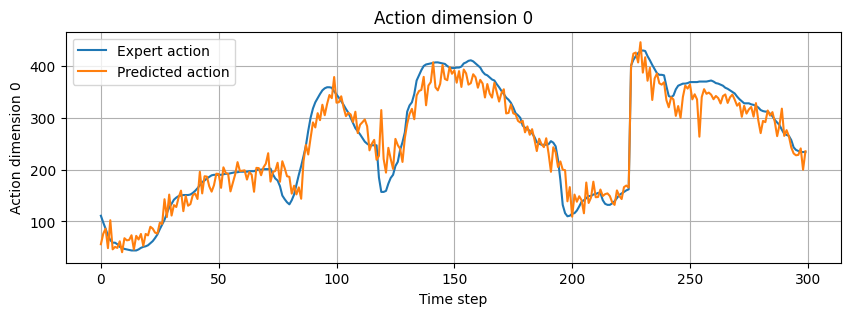

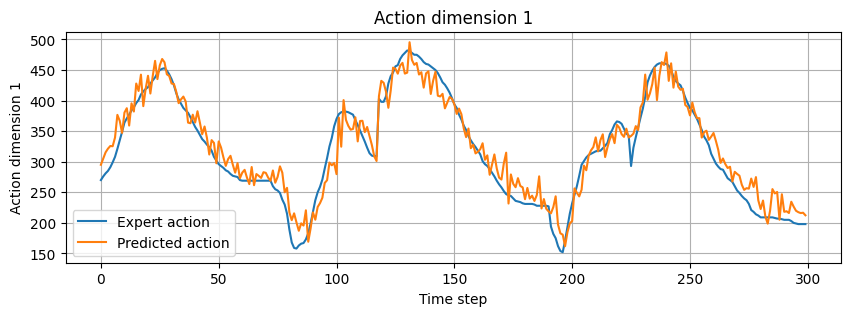

In [43]:
smolvla_metrics = evaluate_smolvla_one_step(
    policy=smolvla_policy,
    preprocessor=smolvla_preprocessor,
    postprocessor=smolvla_postprocessor,

    dataset=smolvla_val_dataset,

    image_key=image_key,
    state_key=state_key,
    action_key=action_key,

    task="Push the T-shaped block to the target",
)

print(
    "SmolVLA MAE:",
    smolvla_metrics["mae"],
)

print(
    "SmolVLA MSE:",
    smolvla_metrics["mse"],
)


display(
    per_action_dim_metrics(
        smolvla_metrics["y_true"],
        smolvla_metrics["y_pred"],
    )
)

plot_action_trajectory(
    smolvla_metrics["y_true"],
    smolvla_metrics["y_pred"],
)